In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mashlyn/online-retail-ii-uci/online_retail_II.csv


# =============================================================
# PROJECT 5: CUSTOMER SEGMENTATION AND RFM ANALYSIS
# Analyst: Ibtisam Ahmed Khan
# Dataset: Online Retail II — UK Gift Retailer (UCI / Kaggle)
# =============================================================
# Business Questions:
# 1. Who are our most valuable customers?
# 2. Which customers are we about to lose?
# 3. How do we treat each segment differently?
# 4. What does customer retention look like over time?
# 5. Which segments drive the most revenue?
# =============================================================
 
# ─────────────────────────────────────────────────────────────
# SECTION 0 — SETUP
# ─────────────────────────────────────────────────────────────

In [2]:
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family']    = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 14
plt.rcParams['axes.titleweight']  = 'bold'
plt.rcParams['axes.titlepad']     = 12
 
BLUE   = '#1a3c6e'
GREEN  = '#1D9E75'
AMBER  = '#EF9F27'
RED    = '#E24B4A'
GRAY   = '#888780'
PURPLE = '#534AB7'
 
print("Setup complete.")

Setup complete.


# ─────────────────────────────────────────────────────────────
# SECTION 1 — LOAD AND INSPECT
# ─────────────────────────────────────────────────────────────
 

In [3]:

print("\n" + "="*60)
print("SECTION 1: LOAD AND INSPECT")
print("="*60)
 
df = pd.read_csv(
    '/kaggle/input/datasets/mashlyn/online-retail-ii-uci/online_retail_II.csv',
    encoding='latin-1',
    parse_dates=['InvoiceDate']
)
 
print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDate range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
print(f"\nUnique countries: {df['Country'].nunique()}")
print(f"Top 5 countries:\n{df['Country'].value_counts().head()}")
print(f"\nSample invoice numbers: {df['Invoice'].unique()[:10]}")
 


SECTION 1: LOAD AND INSPECT

Shape: 1,067,371 rows × 8 columns

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First 5 rows:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  

Data types:
Invoice        

# ─────────────────────────────────────────────────────────────
# SECTION 2 — DATA CLEANING
# ─────────────────────────────────────────────────────────────
 

In [4]:

print("\n" + "="*60)
print("SECTION 2: DATA CLEANING")
print("="*60)
 
print(f"\nOriginal rows: {len(df):,}")
 
# Remove cancelled orders (Invoice starts with C)
cancelled = df[df['Invoice'].astype(str).str.startswith('C')]
print(f"Cancelled orders removed: {len(cancelled):,}")
df = df[~df['Invoice'].astype(str).str.startswith('C')]
 
# Remove rows with missing Customer ID
missing_cust = df['Customer ID'].isnull().sum()
print(f"Rows with missing Customer ID removed: {missing_cust:,}")
df = df.dropna(subset=['Customer ID'])
 
# Remove negative or zero quantity
neg_qty = (df['Quantity'] <= 0).sum()
print(f"Rows with negative/zero quantity removed: {neg_qty:,}")
df = df[df['Quantity'] > 0]
 
# Remove negative or zero price
neg_price = (df['Price'] <= 0).sum()
print(f"Rows with negative/zero price removed: {neg_price:,}")
df = df[df['Price'] > 0]
 
# Focus on UK customers for this analysis
uk_df = df[df['Country'] == 'United Kingdom'].copy()
print(f"\nUK-only dataset: {len(uk_df):,} rows")
print(f"Unique UK customers: {uk_df['Customer ID'].nunique():,}")
 
# Calculate revenue per row
uk_df['Revenue'] = uk_df['Quantity'] * uk_df['Price']
uk_df['Customer ID'] = uk_df['Customer ID'].astype(int)
uk_df['InvoiceMonth'] = uk_df['InvoiceDate'].dt.to_period('M')
uk_df['InvoiceDate_only'] = uk_df['InvoiceDate'].dt.date
 
print(f"\nClean UK dataset: {len(uk_df):,} rows")
print(f"\nKey metrics:")
print(f"  Total revenue:    £{uk_df['Revenue'].sum():,.2f}")
print(f"  Total invoices:   {uk_df['Invoice'].nunique():,}")
print(f"  Total customers:  {uk_df['Customer ID'].nunique():,}")
print(f"  Total products:   {uk_df['StockCode'].nunique():,}")
print(f"  Avg order value:  £{uk_df.groupby('Invoice')['Revenue'].sum().mean():,.2f}")
 



SECTION 2: DATA CLEANING

Original rows: 1,067,371
Cancelled orders removed: 19,494
Rows with missing Customer ID removed: 242,257
Rows with negative/zero quantity removed: 0
Rows with negative/zero price removed: 71

UK-only dataset: 725,250 rows
Unique UK customers: 5,350

Clean UK dataset: 725,250 rows

Key metrics:
  Total revenue:    £14,723,147.52
  Total invoices:   33,541
  Total customers:  5,350
  Total products:   4,616
  Avg order value:  £438.96



# ─────────────────────────────────────────────────────────────
# SECTION 3 — RFM CALCULATION
# ─────────────────────────────────────────────────────────────
 

In [5]:

print("\n" + "="*60)
print("SECTION 3: RFM CALCULATION")
print("="*60)
 
print("""
What is RFM?
────────────
R = Recency   — how recently did the customer buy?
F = Frequency — how many times have they bought?
M = Monetary  — how much have they spent in total?
 
Each customer gets a score of 1-4 on each dimension.
4 is the best score. 1 is the worst.
Combined they tell us who our best customers are.
""")
 
# Reference date — one day after last transaction
reference_date = uk_df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date for recency calculation: {reference_date.date()}")
 
# Calculate RFM values per customer
rfm = uk_df.groupby('Customer ID').agg(
    last_purchase  = ('InvoiceDate', 'max'),
    frequency      = ('Invoice', 'nunique'),
    monetary       = ('Revenue', 'sum')
).reset_index()
 
# Recency = days since last purchase (lower is better)
rfm['recency'] = (reference_date - rfm['last_purchase']).dt.days
 
print(f"\nRFM value summary:")
print(rfm[['recency', 'frequency', 'monetary']].describe().round(2))
 
# Score each dimension 1-4
# Recency: lower days = better = higher score
rfm['R'] = pd.qcut(rfm['recency'],  q=4, labels=[4, 3, 2, 1]).astype(int)
 
# Frequency: higher = better = higher score
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
 
# Monetary: higher = better = higher score
rfm['M'] = pd.qcut(rfm['monetary'].rank(method='first'),  q=4, labels=[1, 2, 3, 4]).astype(int)
 
# Combined RFM score
rfm['RFM_score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm['RFM_total'] = rfm['R'] + rfm['F'] + rfm['M']
 
print(f"\nRFM scores assigned to {len(rfm):,} customers")
print(f"\nSample RFM table:")
print(rfm.head(10).to_string(index=False))
 


SECTION 3: RFM CALCULATION

What is RFM?
────────────
R = Recency   — how recently did the customer buy?
F = Frequency — how many times have they bought?
M = Monetary  — how much have they spent in total?
 
Each customer gets a score of 1-4 on each dimension.
4 is the best score. 1 is the worst.
Combined they tell us who our best customers are.

Reference date for recency calculation: 2011-12-10

RFM value summary:
       recency  frequency   monetary
count  5350.00    5350.00    5350.00
mean    203.00       6.27    2751.99
std     209.96      12.00   12080.47
min       1.00       1.00       2.95
25%      26.00       1.00     336.17
50%      98.50       3.00     849.91
75%     382.00       7.00    2214.91
max     739.00     336.00  608821.65

RFM scores assigned to 5,350 customers

Sample RFM table:
 Customer ID       last_purchase  frequency  monetary  recency  R  F  M RFM_score  RFM_total
       12346 2011-01-18 10:01:00         12  77556.46      326  2  4  4       244         10
  


# ─────────────────────────────────────────────────────────────
# SECTION 4 — CUSTOMER SEGMENTATION
# ─────────────────────────────────────────────────────────────
 


In [6]:

print("\n" + "="*60)
print("SECTION 4: CUSTOMER SEGMENTATION")
print("="*60)
 
print("""
Segment definitions:
────────────────────
Champion:         R=4, F=4 or F=3, bought recently and often
Loyal:            F>=3, buy consistently
Potential Loyal:  R>=3, F=2, recent buyers with growing frequency
New Customer:     R=4, F=1, just bought for the first time
At Risk:          R<=2, F>=3, used to buy often but gone quiet
Cannot Lose:      R=1, F=4, highest frequency but not buying recently
Hibernating:      R<=2, F<=2, low engagement across the board
Lost:             R=1, F=1, bought once a long time ago
""")
 
def assign_segment(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 4 and f >= 3:
        return 'Champion'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 3 and f == 2:
        return 'Potential Loyal'
    elif r == 4 and f == 1:
        return 'New Customer'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'Cannot Lose'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and r > 1:
        return 'Hibernating'
    else:
        return 'Lost'
 
rfm['Segment'] = rfm.apply(assign_segment, axis=1)
 
# Segment summary
seg_summary = rfm.groupby('Segment').agg(
    customers      = ('Customer ID', 'count'),
    avg_recency    = ('recency', 'mean'),
    avg_frequency  = ('frequency', 'mean'),
    avg_monetary   = ('monetary', 'mean'),
    total_revenue  = ('monetary', 'sum')
).reset_index()
 
seg_summary['revenue_share'] = seg_summary['total_revenue'] / seg_summary['total_revenue'].sum() * 100
seg_summary['pct_customers'] = seg_summary['customers'] / seg_summary['customers'].sum() * 100
seg_summary = seg_summary.sort_values('total_revenue', ascending=False)
 
print(f"\nSegment breakdown:")
print(seg_summary.round(2).to_string(index=False))
 


SECTION 4: CUSTOMER SEGMENTATION

Segment definitions:
────────────────────
Champion:         R=4, F=4 or F=3, bought recently and often
Loyal:            F>=3, buy consistently
Potential Loyal:  R>=3, F=2, recent buyers with growing frequency
New Customer:     R=4, F=1, just bought for the first time
At Risk:          R<=2, F>=3, used to buy often but gone quiet
Cannot Lose:      R=1, F=4, highest frequency but not buying recently
Hibernating:      R<=2, F<=2, low engagement across the board
Lost:             R=1, F=1, bought once a long time ago


Segment breakdown:
        Segment  customers  avg_recency  avg_frequency  avg_monetary  total_revenue  revenue_share  pct_customers
       Champion       1059        11.55          16.08       7893.46     8359170.46          56.78          19.79
          Loyal        803        54.23           8.62       3430.82     2754946.43          18.71          15.01
    Cannot Lose        607       267.53           7.42       3041.43     1846145.2


# ─────────────────────────────────────────────────────────────
# SECTION 5 — SEGMENT VISUALISATIONS
# ─────────────────────────────────────────────────────────────
 


SECTION 5: SEGMENT VISUALISATIONS


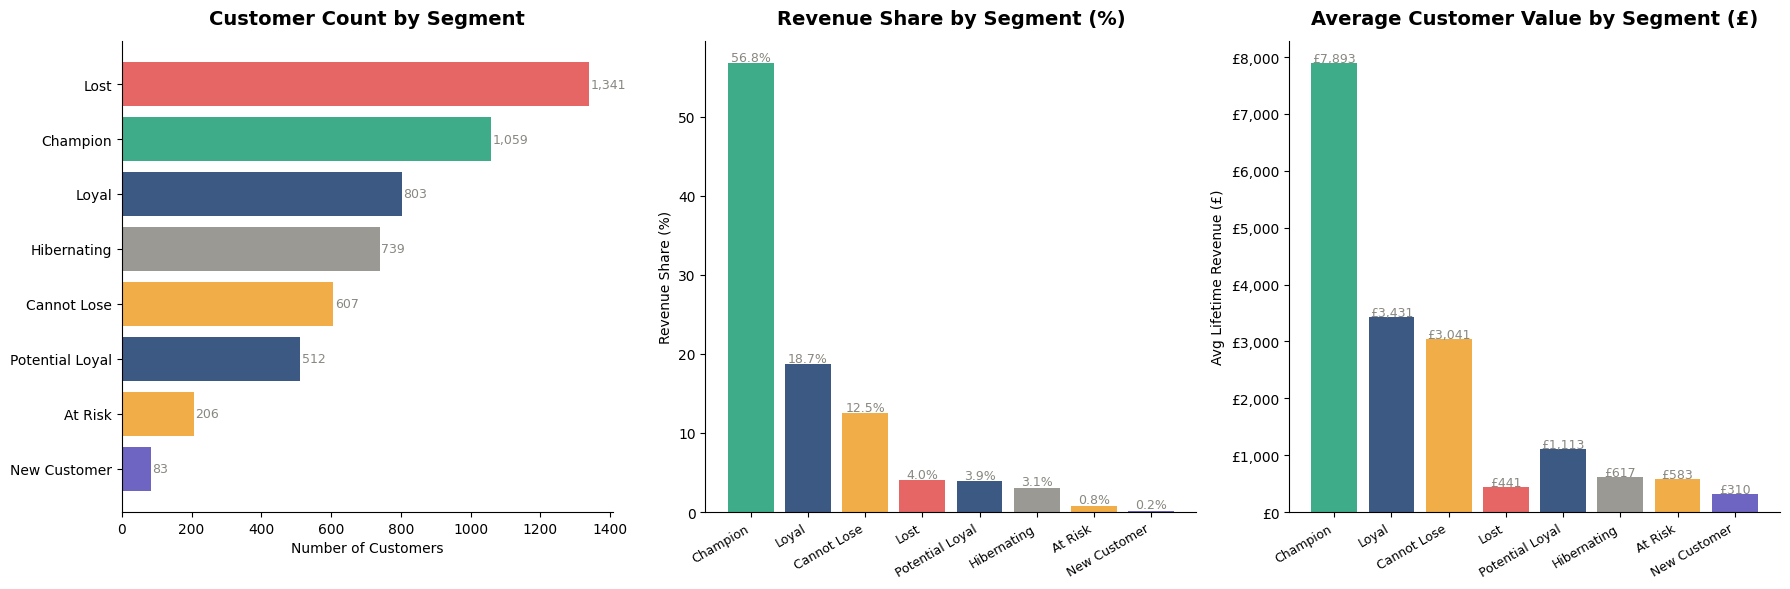

In [7]:

print("\n" + "="*60)
print("SECTION 5: SEGMENT VISUALISATIONS")
print("="*60)
 
seg_colors = {
    'Champion':       GREEN,
    'Loyal':          BLUE,
    'Potential Loyal':BLUE,
    'New Customer':   PURPLE,
    'Cannot Lose':    AMBER,
    'At Risk':        AMBER,
    'Hibernating':    GRAY,
    'Lost':           RED
}
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
 
# Customer count per segment
seg_order = seg_summary.sort_values('customers', ascending=False)['Segment'].tolist()
colors1 = [seg_colors.get(s, GRAY) for s in seg_order]
counts  = [seg_summary[seg_summary['Segment']==s]['customers'].values[0] for s in seg_order]
axes[0].barh(seg_order[::-1], counts[::-1], color=colors1[::-1], alpha=0.85)
axes[0].set_title('Customer Count by Segment')
axes[0].set_xlabel('Number of Customers')
for i, (s, c) in enumerate(zip(seg_order[::-1], counts[::-1])):
    axes[0].text(c + 5, i, f'{c:,}', va='center', fontsize=9, color=GRAY)
 
# Revenue share per segment
seg_rev_order = seg_summary['Segment'].tolist()
colors2 = [seg_colors.get(s, GRAY) for s in seg_rev_order]
rev_shares = seg_summary['revenue_share'].tolist()
axes[1].bar(range(len(seg_rev_order)), rev_shares, color=colors2, alpha=0.85)
axes[1].set_title('Revenue Share by Segment (%)')
axes[1].set_ylabel('Revenue Share (%)')
axes[1].set_xticks(range(len(seg_rev_order)))
axes[1].set_xticklabels(seg_rev_order, rotation=30, ha='right', fontsize=9)
for i, v in enumerate(rev_shares):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9, color=GRAY)
 
# Avg monetary value per segment
avg_mon = seg_summary['avg_monetary'].tolist()
colors3 = [seg_colors.get(s, GRAY) for s in seg_rev_order]
axes[2].bar(range(len(seg_rev_order)), avg_mon, color=colors3, alpha=0.85)
axes[2].set_title('Average Customer Value by Segment (£)')
axes[2].set_ylabel('Avg Lifetime Revenue (£)')
axes[2].set_xticks(range(len(seg_rev_order)))
axes[2].set_xticklabels(seg_rev_order, rotation=30, ha='right', fontsize=9)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
for i, v in enumerate(avg_mon):
    axes[2].text(i, v + 20, f'£{v:,.0f}', ha='center', fontsize=9, color=GRAY)
 
plt.tight_layout()
plt.savefig('segment_overview.png', dpi=150, bbox_inches='tight')
plt.show()
 


 
# ─────────────────────────────────────────────────────────────
# SECTION 6 — RFM SCATTER PLOT
# ─────────────────────────────────────────────────────────────
 


SECTION 6: RFM SCATTER — FREQUENCY VS MONETARY


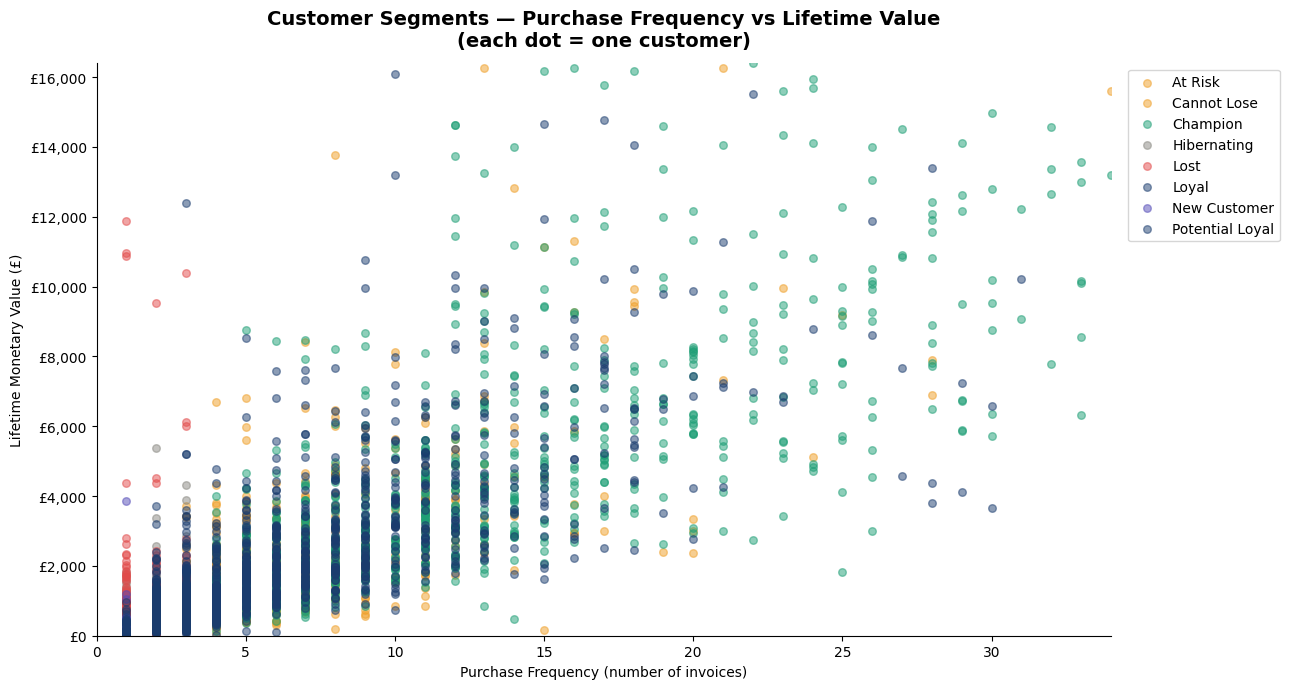

Champions (top right) = high frequency, high value — your best customers
Lost (bottom left) = bought once, low value, long time ago


In [9]:
print("\n" + "="*60)
print("SECTION 6: RFM SCATTER — FREQUENCY VS MONETARY")
print("="*60)
 
fig, ax = plt.subplots(figsize=(13, 7))
 
for segment, group in rfm.groupby('Segment'):
    color = seg_colors.get(segment, GRAY)
    ax.scatter(
        group['frequency'],
        group['monetary'],
        c=color,
        alpha=0.5,
        s=30,
        label=segment
    )
 
ax.set_title('Customer Segments — Purchase Frequency vs Lifetime Value\n(each dot = one customer)')
ax.set_xlabel('Purchase Frequency (number of invoices)')
ax.set_ylabel('Lifetime Monetary Value (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
ax.set_xlim(0, rfm['frequency'].quantile(0.98))
ax.set_ylim(0, rfm['monetary'].quantile(0.98))
 
plt.tight_layout()
plt.savefig('rfm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("Champions (top right) = high frequency, high value — your best customers")
print("Lost (bottom left) = bought once, low value, long time ago")
 

# ─────────────────────────────────────────────────────────────
# SECTION 7 — COHORT RETENTION ANALYSIS
# ─────────────────────────────────────────────────────────────
 

In [11]:

print("\n" + "="*60)
print("SECTION 7: COHORT RETENTION ANALYSIS")
print("="*60)
 
print("""
What is cohort analysis?
────────────────────────
A cohort is a group of customers who made their FIRST purchase
in the same month. We then track what percentage of each cohort
is still buying in the following months.
 
Example:
  January cohort = 500 customers who bought for the first time in Jan
  In February: 200 of them bought again = 40% retention
  In March:    150 of them bought again = 30% retention
  In April:    100 of them bought again = 20% retention
 
This tells us whether the business is getting better or worse
at keeping customers over time.
""")
 
# Assign cohort to each customer (month of first purchase)
uk_df['CohortMonth'] = uk_df.groupby('Customer ID')['InvoiceMonth'].transform('min')
 
# Get unique customer-month combinations
cohort_data = uk_df.groupby(['Customer ID', 'InvoiceMonth', 'CohortMonth']).agg(
    revenue = ('Revenue', 'sum')
).reset_index()
 
# Calculate cohort index (months since first purchase)
cohort_data['CohortIndex'] = (
    cohort_data['InvoiceMonth'].dt.to_timestamp() -
    cohort_data['CohortMonth'].dt.to_timestamp()
).dt.days // 30
 
# Cohort size (how many customers in each cohort)
cohort_size = cohort_data[cohort_data['CohortIndex'] == 0].groupby('CohortMonth')['Customer ID'].nunique()
 
# Retention matrix — customers active in each month
retention_matrix = cohort_data.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().unstack()
 
# Convert to percentage of original cohort
retention_pct = retention_matrix.divide(cohort_size, axis=0) * 100
 
# Keep only first 12 months and recent cohorts
retention_pct = retention_pct.iloc[:, :13]
retention_pct = retention_pct.dropna(how='all')
 
print(f"\nRetention matrix shape: {retention_pct.shape}")
print(f"\nFirst 6 cohorts, first 6 months:")
print(retention_pct.iloc[:6, :6].round(1).to_string())
 


SECTION 7: COHORT RETENTION ANALYSIS

What is cohort analysis?
────────────────────────
A cohort is a group of customers who made their FIRST purchase
in the same month. We then track what percentage of each cohort
is still buying in the following months.
 
Example:
  January cohort = 500 customers who bought for the first time in Jan
  In February: 200 of them bought again = 40% retention
  In March:    150 of them bought again = 30% retention
  In April:    100 of them bought again = 20% retention
 
This tells us whether the business is getting better or worse
at keeping customers over time.


Retention matrix shape: (25, 13)

First 6 cohorts, first 6 months:
CohortIndex      0     1     2     3     4     5
CohortMonth                                     
2009-12      100.0  35.2  33.0  42.3  37.8  35.7
2010-01      100.0  42.6   NaN  31.3  26.1  31.9
2010-02      100.0  22.2  30.3   NaN  24.2  20.7
2010-03      100.0  19.7  23.8  24.8  23.5  21.1
2010-04      100.0  19.3  20.4  16.


# ─────────────────────────────────────────────────────────────
# SECTION 8 — COHORT HEATMAP
# ─────────────────────────────────────────────────────────────
 



SECTION 8: COHORT RETENTION HEATMAP


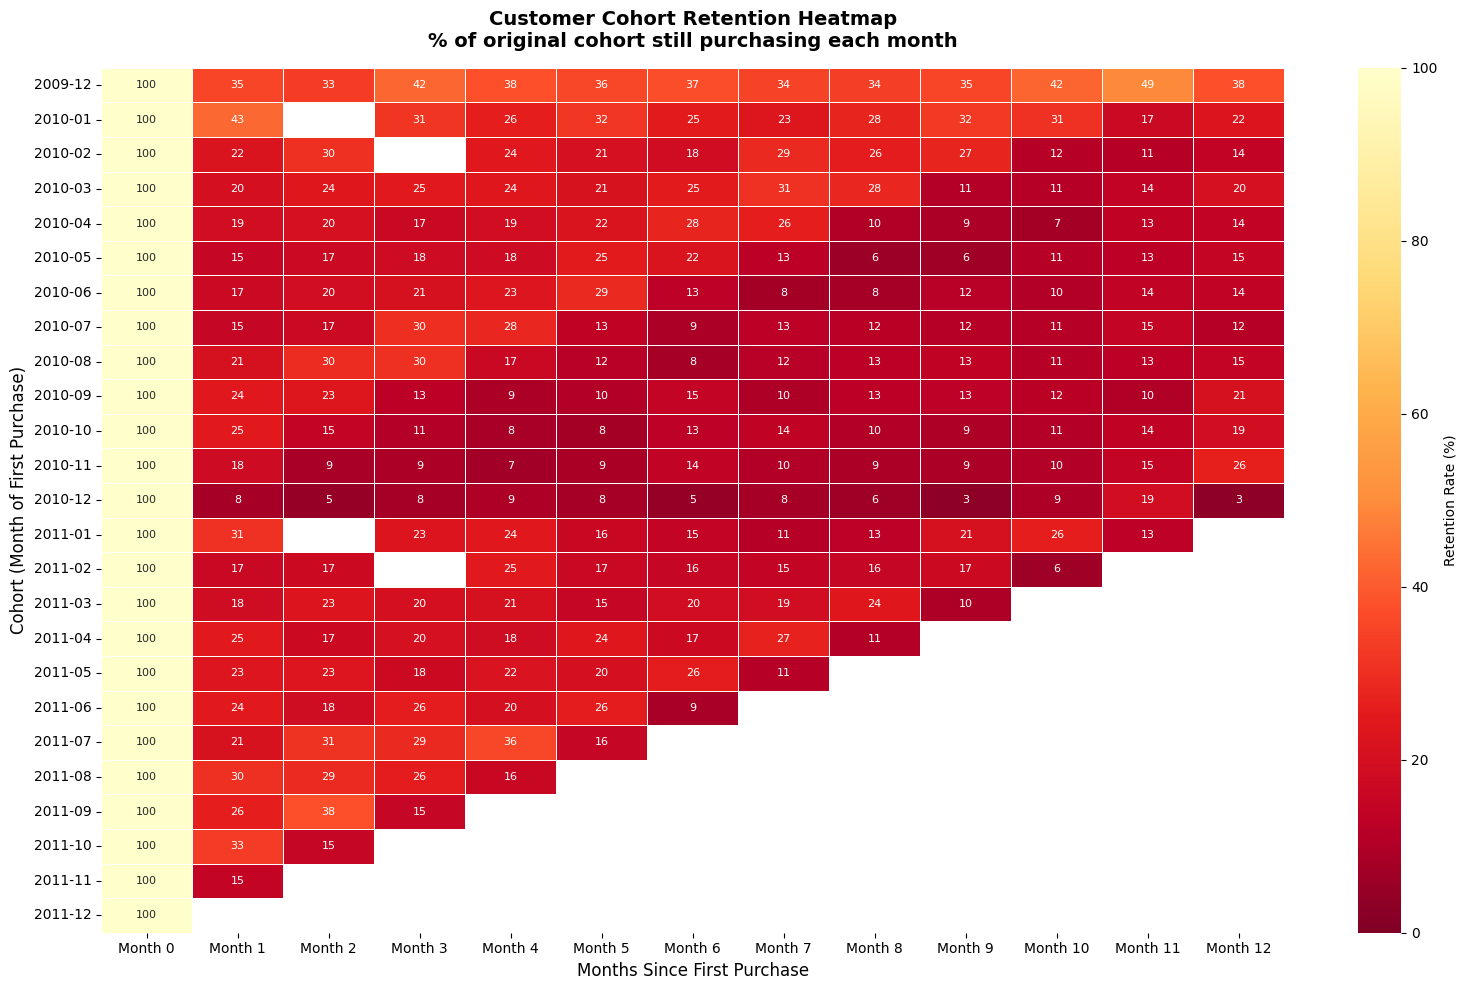


How to read this heatmap:
  Each ROW is one cohort (customers who first bought that month)
  Month 0 = always 100% (everyone bought in their first month)
  Month 1 = what % came back next month
  Month 3 = what % came back 3 months later
 
  Darker red = lower retention (bad)
  Darker yellow/green = higher retention (good)
 
  If Month 1 retention is consistently below 20%, the business
  has a serious retention problem worth investigating.



In [12]:

print("\n" + "="*60)
print("SECTION 8: COHORT RETENTION HEATMAP")
print("="*60)
 
fig, ax = plt.subplots(figsize=(16, 10))
 
# Format index as string for display
retention_display = retention_pct.copy()
retention_display.index = retention_display.index.astype(str)
retention_display.columns = [f'Month {i}' for i in retention_display.columns]
 
sns.heatmap(
    retention_display,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Retention Rate (%)'},
    vmin=0,
    vmax=100,
    annot_kws={'size': 8}
)
 
ax.set_title('Customer Cohort Retention Heatmap\n% of original cohort still purchasing each month',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months Since First Purchase', fontsize=12)
ax.set_ylabel('Cohort (Month of First Purchase)', fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
 
plt.tight_layout()
plt.savefig('cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("""
How to read this heatmap:
  Each ROW is one cohort (customers who first bought that month)
  Month 0 = always 100% (everyone bought in their first month)
  Month 1 = what % came back next month
  Month 3 = what % came back 3 months later
 
  Darker red = lower retention (bad)
  Darker yellow/green = higher retention (good)
 
  If Month 1 retention is consistently below 20%, the business
  has a serious retention problem worth investigating.
""")


# ─────────────────────────────────────────────────────────────
# SECTION 9 — REVENUE BY COHORT OVER TIME
# ─────────────────────────────────────────────────────────────
 



SECTION 9: REVENUE BY COHORT OVER TIME


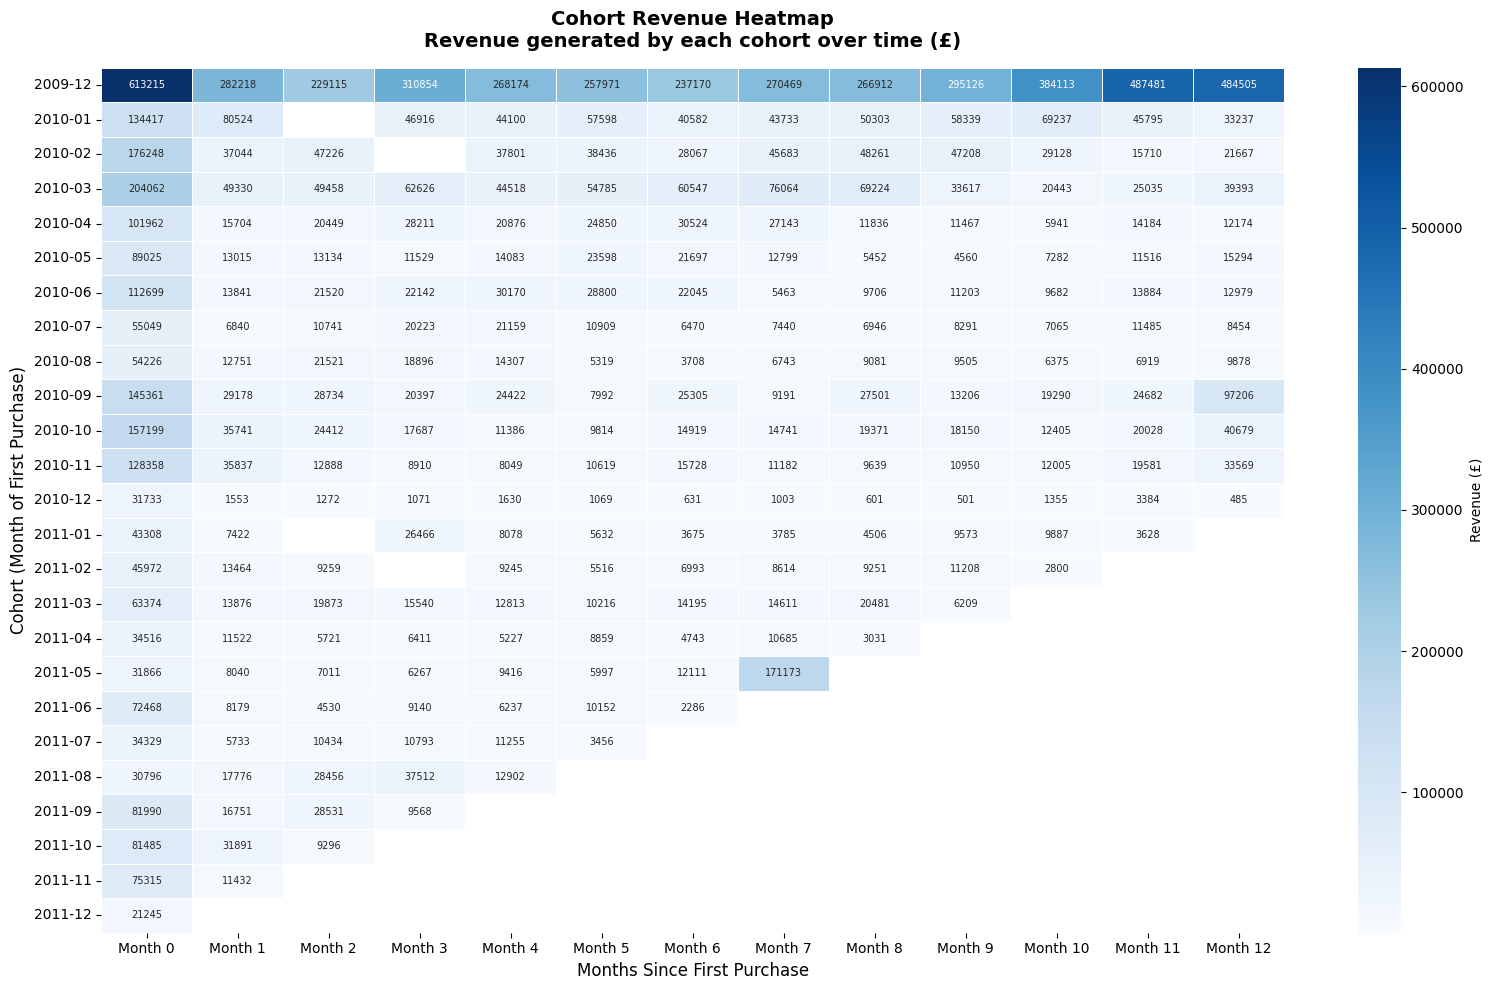

In [13]:

print("\n" + "="*60)
print("SECTION 9: REVENUE BY COHORT OVER TIME")
print("="*60)
 
# Revenue matrix
revenue_matrix = cohort_data.groupby(['CohortMonth', 'CohortIndex'])['revenue'].sum().unstack()
revenue_matrix = revenue_matrix.iloc[:, :13].dropna(how='all')
revenue_display = revenue_matrix.copy()
revenue_display.index = revenue_display.index.astype(str)
revenue_display.columns = [f'Month {i}' for i in revenue_display.columns]
 
fig, ax = plt.subplots(figsize=(16, 10))
 
sns.heatmap(
    revenue_display,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Revenue (£)'},
    annot_kws={'size': 7}
)
 
ax.set_title('Cohort Revenue Heatmap\nRevenue generated by each cohort over time (£)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months Since First Purchase', fontsize=12)
ax.set_ylabel('Cohort (Month of First Purchase)', fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
 
plt.tight_layout()
plt.savefig('cohort_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
 
 

# ─────────────────────────────────────────────────────────────
# SECTION 10 — TOP PRODUCTS BY SEGMENT
# ─────────────────────────────────────────────────────────────
 

In [14]:

print("\n" + "="*60)
print("SECTION 10: TOP PRODUCTS BY SEGMENT")
print("="*60)
 
# Merge segment back to transactions
uk_with_seg = uk_df.merge(
    rfm[['Customer ID', 'Segment', 'R', 'F', 'M', 'RFM_total']],
    on='Customer ID', how='left'
)
 
# Top products for Champions vs At Risk
for seg in ['Champion', 'At Risk', 'Lost']:
    seg_data = uk_with_seg[uk_with_seg['Segment'] == seg]
    top_products = seg_data.groupby('Description')['Revenue'].sum().nlargest(5)
    print(f"\nTop 5 products for {seg} customers:")
    for product, revenue in top_products.items():
        print(f"  £{revenue:>8,.2f}  {product[:50]}")
 


SECTION 10: TOP PRODUCTS BY SEGMENT

Top 5 products for Champion customers:
  £153,850.65  REGENCY CAKESTAND 3 TIER
  £133,974.02  WHITE HANGING HEART T-LIGHT HOLDER
  £83,600.09  JUMBO BAG RED RETROSPOT
  £81,055.30  ASSORTED COLOUR BIRD ORNAMENT
  £54,131.84  CHILLI LIGHTS

Top 5 products for At Risk customers:
  £2,209.40  WHITE HANGING HEART T-LIGHT HOLDER
  £1,360.95  REGENCY CAKESTAND 3 TIER
  £  989.15  PARTY BUNTING
  £  763.88  ASSORTED COLOUR BIRD ORNAMENT
  £  663.45  WOODEN ROUNDERS GARDEN SET 

Top 5 products for Lost customers:
  £24,747.38  Manual
  £7,168.35  REGENCY CAKESTAND 3 TIER
  £6,121.35  WHITE HANGING HEART T-LIGHT HOLDER
  £4,428.70  LUNCH BAG  BLACK SKULL.
  £3,991.65  LUNCH BAG CARS BLUE


# ─────────────────────────────────────────────────────────────
# SECTION 11 — MONTHLY REVENUE TREND
# ─────────────────────────────────────────────────────────────
 


SECTION 11: MONTHLY REVENUE TREND


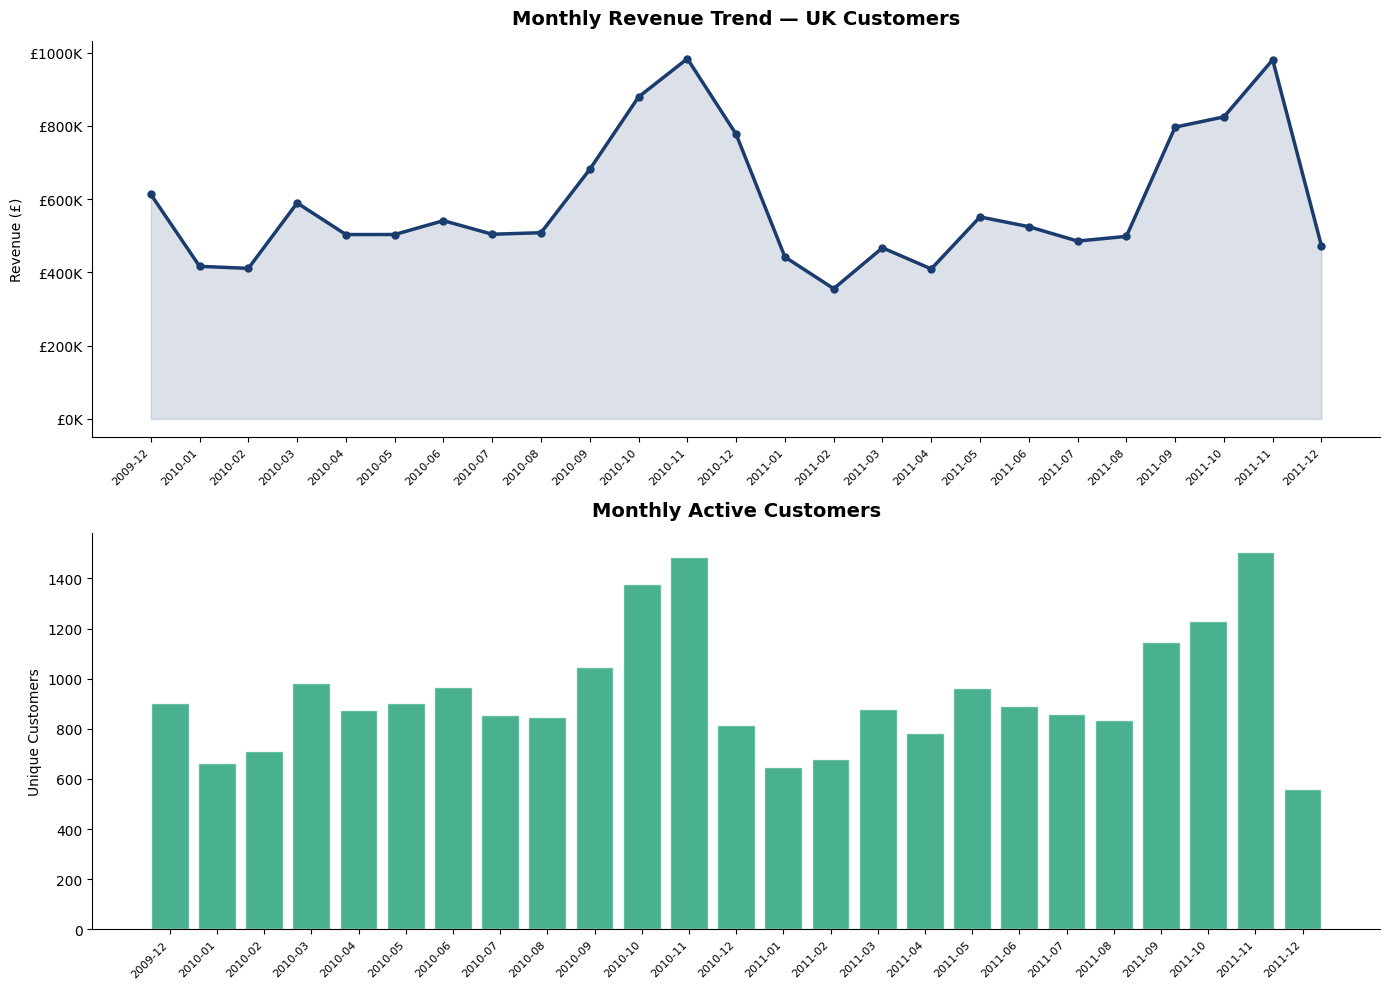

In [15]:

print("\n" + "="*60)
print("SECTION 11: MONTHLY REVENUE TREND")
print("="*60)
 
monthly_rev = uk_df.groupby('InvoiceMonth').agg(
    revenue    = ('Revenue', 'sum'),
    orders     = ('Invoice', 'nunique'),
    customers  = ('Customer ID', 'nunique')
).reset_index()
monthly_rev['InvoiceMonth_str'] = monthly_rev['InvoiceMonth'].astype(str)
monthly_rev['avg_order_value']  = monthly_rev['revenue'] / monthly_rev['orders']
 
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
 
# Revenue trend
axes[0].fill_between(range(len(monthly_rev)), monthly_rev['revenue'],
                     alpha=0.15, color=BLUE)
axes[0].plot(range(len(monthly_rev)), monthly_rev['revenue'],
             color=BLUE, linewidth=2.5, marker='o', markersize=5)
axes[0].set_title('Monthly Revenue Trend — UK Customers')
axes[0].set_ylabel('Revenue (£)')
axes[0].set_xticks(range(len(monthly_rev)))
axes[0].set_xticklabels(monthly_rev['InvoiceMonth_str'], rotation=45, ha='right', fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
 
# Active customers per month
axes[1].bar(range(len(monthly_rev)), monthly_rev['customers'],
            color=GREEN, alpha=0.8, edgecolor='white')
axes[1].set_title('Monthly Active Customers')
axes[1].set_ylabel('Unique Customers')
axes[1].set_xticks(range(len(monthly_rev)))
axes[1].set_xticklabels(monthly_rev['InvoiceMonth_str'], rotation=45, ha='right', fontsize=8)
 
plt.tight_layout()
plt.savefig('monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
 


# ─────────────────────────────────────────────────────────────
# SECTION 12 — FINDINGS AND RECOMMENDATIONS
# ─────────────────────────────────────────────────────────────
 

In [17]:

print("\n" + "="*60)
print("SECTION 12: FINDINGS AND RECOMMENDATIONS")
print("="*60)
 
champion_count  = (rfm['Segment'] == 'Champion').sum()
lost_count      = (rfm['Segment'] == 'Lost').sum()
at_risk_count   = (rfm['Segment'] == 'At Risk').sum()
cannot_lose     = (rfm['Segment'] == 'Cannot Lose').sum()
total_customers = len(rfm)
 
champion_rev = seg_summary[seg_summary['Segment']=='Champion']['total_revenue'].values
at_risk_rev  = seg_summary[seg_summary['Segment']=='At Risk']['total_revenue'].values
lost_rev     = seg_summary[seg_summary['Segment']=='Lost']['total_revenue'].values
 
avg_m1_retention = retention_pct.iloc[:, 1].mean() if retention_pct.shape[1] > 1 else 0
avg_m3_retention = retention_pct.iloc[:, 3].mean() if retention_pct.shape[1] > 3 else 0
 
findings = f"""
╔══════════════════════════════════════════════════════════════╗
║    CUSTOMER SEGMENTATION AND RFM ANALYSIS — FINDINGS BRIEF   ║
║                  Analyst: Ibtisam Ahmed Khan                  ║
╚══════════════════════════════════════════════════════════════╝
 
DATASET
  Source:   Online Retail II — UK Gift Retailer (UCI / Kaggle)
  Period:   {uk_df['InvoiceDate'].min().strftime('%B %Y')} to {uk_df['InvoiceDate'].max().strftime('%B %Y')}
  Customers:{total_customers:,} unique UK customers analysed
  Revenue:  £{uk_df['Revenue'].sum():,.2f} total
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 
FINDING 1 — CHAMPION CUSTOMERS ARE THE BUSINESS
  {champion_count:,} customers ({champion_count/total_customers:.1%} of base) are Champions —
  bought recently and frequently.
  {'Revenue from Champions: £' + f'{champion_rev[0]:,.2f}' if len(champion_rev) > 0 else ''}
  These customers should receive VIP treatment — early access,
  personalised outreach, and loyalty rewards.
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 
FINDING 2 — AT RISK CUSTOMERS REPRESENT RECOVERABLE REVENUE
  {at_risk_count:,} customers ({at_risk_count/total_customers:.1%}) used to buy frequently
  but have gone quiet recently.
  {'Revenue at risk: £' + f'{at_risk_rev[0]:,.2f}' if len(at_risk_rev) > 0 else ''}
  These customers have demonstrated they like the product —
  they just need a reason to come back.
 
RECOMMENDATION 2:
  Launch a win-back campaign for At Risk customers —
  personalised email referencing their last purchase category,
  with a time-limited incentive. Target: reactivate 20%.
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 
FINDING 3 — RETENTION DROPS SHARPLY AFTER MONTH 1
  Average Month 1 retention: {avg_m1_retention:.1f}%
  Average Month 3 retention: {avg_m3_retention:.1f}%
  Most customers who buy once never return. The biggest
  opportunity is converting first-time buyers into
  second-time buyers — this one step dramatically
  increases predicted lifetime value.
 
RECOMMENDATION 3:
  Implement a post-purchase email sequence triggered
  48 hours after first delivery — personalised product
  recommendations based on first purchase category.
  Even a 5% improvement in Month 1 retention compounds
  significantly over 12 months.
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 
FINDING 4 — CANNOT LOSE CUSTOMERS NEED URGENT ATTENTION
  {cannot_lose:,} high-frequency customers have not bought recently.
  These are your historically best customers going dark.
  Losing them permanently would have an outsized revenue impact.
 
RECOMMENDATION 4:
  Personally contact Cannot Lose customers — phone or
  personalised direct mail, not generic email. The revenue
  at stake justifies the cost of a high-touch approach.
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 
SEGMENT ACTION PLAN SUMMARY:
 
  Champion      → Reward and retain. Ask for reviews and referrals.
  Loyal         → Upsell. Offer complementary products.
  Potential     → Increase purchase frequency with targeted offers.
  New Customer  → Onboard well. First 30 days are critical.
  At Risk       → Win-back campaign. Act before they become Lost.
  Cannot Lose   → High-touch personal outreach immediately.
  Hibernating   → Low-cost reactivation email. Accept some churn.
  Lost          → Do not spend heavily. Only generic campaigns.
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""
 
print(findings)
 
with open('rfm_findings_brief.txt', 'w') as f:
    f.write(findings)
 
rfm.to_csv('rfm_segments.csv', index=False)
print("\nFiles saved:")
print("  rfm_segments.csv — customer RFM scores and segments")
print("  rfm_findings_brief.txt — plain language findings")
print("\nProject 5 complete.")
 


SECTION 12: FINDINGS AND RECOMMENDATIONS

╔══════════════════════════════════════════════════════════════╗
║    CUSTOMER SEGMENTATION AND RFM ANALYSIS — FINDINGS BRIEF   ║
║                  Analyst: Ibtisam Ahmed Khan                  ║
╚══════════════════════════════════════════════════════════════╝
 
DATASET
  Source:   Online Retail II — UK Gift Retailer (UCI / Kaggle)
  Period:   December 2009 to December 2011
  Customers:5,350 unique UK customers analysed
  Revenue:  £14,723,147.52 total
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 
FINDING 1 — CHAMPION CUSTOMERS ARE THE BUSINESS
  1,059 customers (19.8% of base) are Champions —
  bought recently and frequently.
  Revenue from Champions: £8,359,170.46
  These customers should receive VIP treatment — early access,
  personalised outreach, and loyalty rewards.
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 
FINDING 2 — AT RISK CUSTOMERS REPRESENT RECOVERABLE REVENUE
  206 customers (3.9%) used t